In [1]:
import glob
import re
import numpy as np
import pandas as pd

#files = glob.glob("../results_zcum_*_zLIM*.txt")
files = glob.glob("../profile_zcum_*_zLIM*_*.txt")
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline as cs
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])
import json
from matplotlib import ticker
plt.rcParams['font.family'] = 'serif'


In [2]:

rows = []

zindex_map = {
    11: "zLG",
    0: "zHD",
    9: "zHEL",
    10: "zCMB"
}

re_zlim = re.compile(r"zLIM([0-9.]+)")
re_qm   = re.compile(r"zLIM[0-9.]+_([-0-9.eE]+)\.txt")

buckets = {
    11: [],
    0: [],
    9: [],
    10: []
}


for fname in files:
    # ---- filename parsing (cheap) ----
    zlim = float(re_zlim.search(fname).group(1))
    qm_fix = float(re_qm.search(fname).group(1))

    # ---- read only what we need ----
    df = pd.read_csv(fname)
    df.columns = df.columns.str.strip()
    r = df.iloc[0]

    zindex = int(r.ZINDEX)

    if zindex not in buckets:
        continue

    buckets[zindex].append({
        "zLIM": zlim,
        "QM_FIX": qm_fix,
        "FUN": float(r["FUN"]),
"SUCCESS": bool(r["SUCCESS"])})

        

df_zLG  = pd.DataFrame(buckets[11]).sort_values("zLIM")
df_zHD  = pd.DataFrame(buckets[0]).sort_values("zLIM")
df_zHEL = pd.DataFrame(buckets[9]).sort_values("zLIM")
df_zCMB = pd.DataFrame(buckets[10]).sort_values("zLIM")

# for fname in files:
#     # ---- parse filename ----

#     z_type = re.search(r"results_zcum_(z\w+)_zLIM", fname).group(1)
#     zlim = float(re.search(r"zLIM([0-9.]+)", fname).group(1)[:-1])

#     with open(fname) as f:
#         text = f.read()

#     # ---- parse content ----
#     zindex = int(re.search(r"ZINDEX=\s*(\d+)", text).group(1))
#     min2ll = float(re.search(r"Minimum -2loglike:\s*([-0-9.eE]+)", text).group(1))
#     success = re.search(r"Success:\s*(True|False)", text).group(1) == "True"

#     # best-fit parameters (numpy-style array)
#     params_block = re.search(
#         r"Best-fit parameters:\s*\[([\s\S]*?)\]",
#         text
#     ).group(1)

#     params = np.fromstring(params_block.replace("\n", " "), sep=" ")

#     row = {
#         "file": fname,
#         "z_type": z_type,
#         "zindex": zindex,
#         "zindex_label": zindex_map.get(zindex, "UNKNOWN"),
#         "zLIM": zlim,
#         "min_2loglike": min2ll,
#         "success": success
#     }

#     # store parameters as p0, p1, ...
#     for i, p in enumerate(params):
#         row[f"p{i}"] = p

#     rows.append(row)

# df = pd.DataFrame(rows)

# # sort nicely for plotting
# df = df.sort_values(["z_type", "zLIM"])

# # save
# df.to_csv("combined_results.csv", index=False)

# print("Saved combined_results.csv with shape:", df.shape)


KeyError: 'zLIM'

In [3]:
df_zCMB.to_csv("profile_zCMB_results.txt", index=False)
df_zHEL.to_csv("profile_zHEL_results.txt", index=False)
df_zHD.to_csv("profile_zHD_results.txt", index=False)
df_zLG.to_csv("profile_zLG_results.txt", index=False)

NameError: name 'df_zCMB' is not defined

In [24]:
DELTA_P8 = 0.3
N_SCAN = 31
rows = []
for _, r in dd.iterrows():
    zindex = int(r["zindex"])
    zlim = float(r["zLIM"])
    p8_best = float(r["p8"])

    p8_vals = np.linspace(
        p8_best - DELTA_P8,
        p8_best + DELTA_P8,
        N_SCAN
    )

    for p8 in p8_vals:
        rows.append({
            "zindex": zindex,
            "zLIM": zlim,
            "p8_scan": p8,
        })

In [72]:
df_zLG

,zLIM,QM_FIX,FUN,SUCCESS
374,0.00587,0.539344,-43.591807,True
375,0.00587,0.179344,-39.231777,True
371,0.00587,0.279344,-44.459125,True
380,0.00587,0.659344,-35.902412,True
437,0.00587,0.699344,-32.294844,True
...,...,...,...,...
272,0.10762,0.019793,-602.467839,True
432,0.10762,0.059793,-602.766290,True
290,0.10762,0.079793,-602.883822,True
296,0.10762,0.259793,-602.979381,True


In [29]:
arg_df = pd.DataFrame(rows)
arg_df.to_csv("../../ARGUMENTS/qm_profile_args_age_bias.txt",sep =' ', header=False)

In [4]:
dd = pd.read_csv("combined_results.csv")

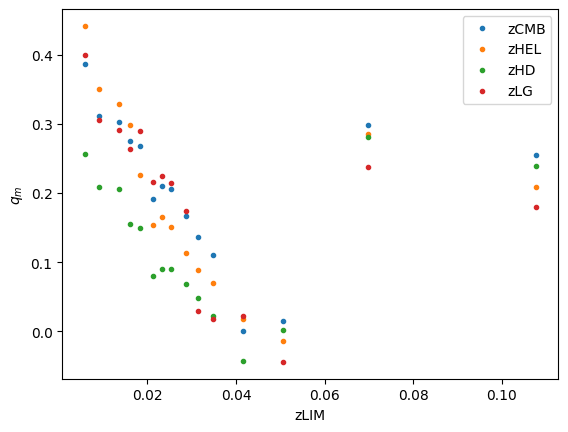

In [5]:
dfcmb = dd[dd["z_type"] == "zCMB"]
dfhel = dd[dd["z_type"] == "zHEL"]
dfhd = dd[dd["z_type"] == "zHD"]
dflg = dd[dd["z_type"] == "zLG"]
plt.plot(dfcmb["zLIM"], dfcmb["p8"], '.')
plt.plot(dfhel["zLIM"], dfhel["p8"], '.')
plt.plot(dfhd["zLIM"], dfhd["p8"], '.')
plt.plot(dflg["zLIM"], dflg["p8"], '.')
plt.xlabel("zLIM")
plt.ylabel("$q_m$")
plt.legend(["zCMB", "zHEL", "zHD", "zLG"])


In [19]:
df_zLG['QM_FIX']

374   -0.103015
372   -0.153015
371   -0.228015
340   -0.403015
346   -0.353015
         ...   
211    0.171358
205   -0.128642
207   -0.353642
201   -0.078642
223   -0.028642
Name: QM_FIX, Length: 375, dtype: float64

In [31]:
dfcmb

,file,z_type,zindex,zindex_label,zLIM,min_2loglike,success,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11
0,../results_zcum_zCMB_zLIM0.00587.txt,zCMB,10,zCMB,0.00587,-6.888363,True,-19.145362,0.168531,0.153709,-0.066322,0.962697,3.226673,-0.042104,0.056121,0.386750,-0.317636,92.968140,0.005940
1,../results_zcum_zCMB_zLIM0.00907.txt,zCMB,10,zCMB,0.00907,-186.260712,True,-19.155945,0.157063,0.158013,-0.058259,0.962146,3.187104,-0.039505,0.055069,0.311367,-0.309293,25.543578,0.010290
2,../results_zcum_zCMB_zLIM0.01351.txt,zCMB,10,zCMB,0.01351,-250.726216,True,-19.153428,0.152574,0.155058,-0.040612,0.955646,3.314226,-0.039363,0.054264,0.303092,-0.297865,13.913004,0.013770
3,../results_zcum_zCMB_zLIM0.01613.txt,zCMB,10,zCMB,0.01613,-399.978380,True,-19.143869,0.146340,0.153531,-0.027645,0.949089,3.315636,-0.040956,0.051709,0.274473,-0.291020,11.560087,0.015950
4,../results_zcum_zCMB_zLIM0.01826.txt,zCMB,10,zCMB,0.01826,-436.008073,True,-19.147307,0.143172,0.154454,-0.007488,0.940595,3.400670,-0.039099,0.051042,0.268520,-0.250806,9.030468,0.019250
5,../results_zcum_zCMB_zLIM0.02121.txt,zCMB,10,zCMB,0.02121,-553.267833,True,-19.169321,0.138830,0.155226,0.021416,0.909986,3.300702,-0.038952,0.050805,0.191571,-0.168952,6.590587,0.022530
6,../results_zcum_zCMB_zLIM0.02324.txt,zCMB,10,zCMB,0.02324,-598.573762,True,-19.162927,0.136744,0.153593,0.038762,0.884849,3.376053,-0.038724,0.050144,0.209622,-0.172098,6.294869,0.022220
7,../results_zcum_zCMB_zLIM0.02531.txt,zCMB,10,zCMB,0.02531,-598.536665,True,-19.139830,0.136840,0.155353,0.044021,0.873601,3.447466,-0.038376,0.049268,0.205931,-0.185764,3.882940,0.026430
8,../results_zcum_zCMB_zLIM0.02873.txt,zCMB,10,zCMB,0.02873,-610.289387,True,-19.137446,0.135563,0.155046,0.059005,0.867125,3.460463,-0.038381,0.047971,0.166786,-0.133790,3.694573,0.028020
9,../results_zcum_zCMB_zLIM0.03139.txt,zCMB,10,zCMB,0.03139,-621.789292,True,-19.139762,0.134859,0.155168,0.073605,0.846426,3.422653,-0.039377,0.048067,0.136203,-0.059322,3.269794,0.032120


In [ ]:
if len(np.array(MLE).shape)>1:
    for i in range(len(MLE)):
        y=np.array(MLE[i])
        x=np.array(x_ar[i])
        print(x)
        print(y)
        spline = cs(x, y-MLE_true[i], bc_type='natural')
        ix=[1,2]
        root= cs(x, y-MLE_true[i]-1, bc_type='natural').roots()
        print(root)
        if len(root)!=2:
            print(root)
            plt.plot(x,y-MLE_true[i])
            print('How come it is here')
            plt.plot(x_true[i],0,'*')
            plt.plot(root[ix],[1,1],'o')
            plt.show()
            ro.append(root[ix])
        else:
            print("2")
            print(root)
            plt.plot(x,y-MLE_true[i])
            
            plt.plot(x_true[i],0,'*')
            plt.plot(root,[1,1],'o')
            plt.show()
            ro.append(root)
            
else:
        y=np.array(MLE)
        x=np.array(x_ar)
        spline = cs(x, y-MLE_true[0], bc_type='natural')
        ix=[0,1]
        root= cs(x, y-MLE_true[0]-1, bc_type='natural').roots()
        if len(root)!=2:
            print(root)
            plt.plot(x,y-MLE_true[0])
            
            plt.plot(x_true[0],0,'*')
            plt.plot(root[ix],[1,1],'o')
            plt.show()
            ro.append(root[ix])
        else:
            print(root)
            plt.plot(x,y-MLE_true[0])
            
            plt.plot(x_true[0],0,'*')
            plt.plot(root,[1,1],'o')
            plt.show()
            ro.append(root)

array([False, False, False])

In [91]:
def analyze_profiles(df_profile, df_bestfit,plot=False):
    final_vals = {}
    qm= []
    mle = []
    roots = []
    for zlim in df_profile['zLIM'].unique():
        df_subset = df_profile[df_profile['zLIM'] == zlim] .sort_values('QM_FIX')
        df_min = df_bestfit[df_bestfit['zLIM'] == zlim]   
        x = df_subset['QM_FIX']
        y = df_subset['FUN'] - df_min['min_2loglike'].values[0]

        root = cs(x,y - 1, bc_type='natural').roots()

        #plt.plot(x,y,'.')


        #plt.plot(df_min['p8'], 0, '*', markersize=10, label=f'Best fit: {np.array(df_min["p8"])[0]:.3f}')
        np.isclose(df_min['p8'],root)
        q_best = np.array(df_min['p8'])[0]
        if len(root) >= 2:
            left_roots  = root[root < q_best]
            right_roots = root[root > q_best]
            roots_phys = []
            if len(left_roots) > 0:
                roots_phys.append(left_roots.max())   # closest from left
            if len(right_roots) > 0:
                roots_phys.append(right_roots.min())  # closest from right
            if plot:
                plt.plot(roots_phys, np.ones_like(roots_phys), 'o', label=f'Roots (±1σ)')
        if plot:
            plt.axhline(y=1, color='k', linestyle='--', alpha=0.3)
            plt.xlabel('$q_m$')
            plt.ylabel('$\Delta(-2\log L)$')
            plt.title(f'zLIM = {zlim:.5f}')
            plt.legend()
            plt.grid(True, alpha=0.3)
        qm.append(np.array(df_min['p8'])[0])
        mle.append(np.array(df_min['min_2loglike'])[0])
        roots.append(roots_phys)
        plt.show()
    final_vals['zLIM'] = df_profile['zLIM'].unique()
    final_vals['QM'] = qm
    final_vals['MLE'] = mle
    final_vals['root'] = roots

    df_return = pd.DataFrame(final_vals)
    return df_return

In [2]:

# df_errors_cmb=analyze_profiles(df_zCMB, dfcmb)
# df_errors_hel=analyze_profiles(df_zHEL, dfhel)
# df_errors_hd=analyze_profiles(df_zHD, dfhd)
# df_errors_lg=analyze_profiles(df_zLG, dflg)


# df_errors_cmb.to_csv("errors_profile_zCMB.txt", index=False)
# df_errors_hel.to_csv("errors_profile_zHEL.txt", index=False)
# df_errors_hd.to_csv("errors_profile_zHD.txt", index=False)
# df_errors_lg.to_csv("errors_profile_zLG.txt", index=False)

df_errors_cmb = pd.read_csv("errors_profile_zCMB.txt", sep=',')
df_errors_hel = pd.read_csv("errors_profile_zHEL.txt", sep=',')
df_errors_hd = pd.read_csv("errors_profile_zHD.txt", sep=',')
df_errors_lg = pd.read_csv("errors_profile_zLG.txt", sep=',')

In [16]:
df_errors_cmb

,zLIM,QM,MLE,root
0,0.00587,0.386750,-6.888363,"[np.float64(0.3057750633842574), np.float64(0...."
1,0.00907,0.311367,-186.260712,"[np.float64(0.23170558588386211), np.float64(0..."
2,0.01351,0.303092,-250.726216,"[np.float64(0.2226615577467205), np.float64(0...."
3,0.01613,0.274473,-399.978380,"[np.float64(0.19443484944501657), np.float64(0..."
4,0.01826,0.268520,-436.008073,"[np.float64(0.18701669282992692), np.float64(0..."
5,0.02121,0.191571,-553.267833,"[np.float64(0.10922572920338358), np.float64(0..."
6,0.02324,0.209622,-598.573762,"[np.float64(0.1250133498088197), np.float64(0...."
7,0.02531,0.205931,-598.536665,"[np.float64(0.11688574455528279), np.float64(0..."
8,0.02873,0.166786,-610.289387,"[np.float64(0.0736248245677855), np.float64(0...."
9,0.03139,0.136203,-621.789292,"[np.float64(0.036596363817370095), np.float64(..."


UFuncTypeError: ufunc 'less' did not contain a loop with signature matching types (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.Float64DType'>) -> None

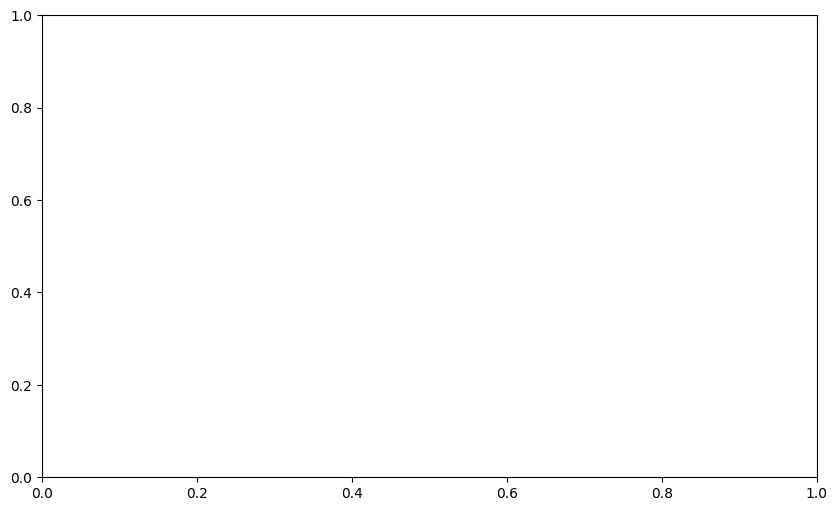

In [9]:

# Plot each redshift frame type
for df_err, df_best, label in [
    (df_errors_cmb, dfcmb, 'zCMB'),
    (df_errors_hel, dfhel, 'zHEL'),
    (df_errors_hd, dfhd, 'zHD'),
    (df_errors_lg, dflg, 'zLG')
]:
    zlims = df_err['zLIM'].values
    qm_best = df_err['QM'].values
    
    # Calculate errors from roots
    fig, ax = plt.subplots(figsize=(10, 6))

    yerr_low = []
    yerr_high = []
    
    for i, roots in enumerate(df_err['root']):
        roots = np.array(roots)
        q_best = qm_best[i]
        
        # Find roots closest to best fit
        left_roots = roots[roots < q_best]
        right_roots = roots[roots > q_best]
        
        if len(left_roots) > 0:
            err_low = q_best - left_roots.max()
        else:
            err_low = 0
            
        if len(right_roots) > 0:
            err_high = right_roots.min() - q_best
        else:
            err_high = 0
            
        yerr_low.append(err_low)
        yerr_high.append(err_high)
    
    # Plot with asymmetric error bars
    ax.errorbar(zlims, qm_best, yerr=[yerr_low, yerr_high], 
                fmt='o', label=label, capsize=3, markersize=5)

    ax.set_xlabel("zLIM")
    ax.set_ylabel("$q_m$")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    plt.tight_layout()
    
    plt.show()

In [2]:
pd.read_csv('errors_profile_zCMB.txt')

,zLIM,QM,MLE,root
0,0.00587,0.386750,-6.888363,"[np.float64(0.3057750633842574), np.float64(0...."
1,0.00907,0.311367,-186.260712,"[np.float64(0.23170558588386211), np.float64(0..."
2,0.01351,0.303092,-250.726216,"[np.float64(0.2226615577467205), np.float64(0...."
3,0.01613,0.274473,-399.978380,"[np.float64(0.19443484944501657), np.float64(0..."
4,0.01826,0.268520,-436.008073,"[np.float64(0.18701669282992692), np.float64(0..."
5,0.02121,0.191571,-553.267833,"[np.float64(0.10922572920338358), np.float64(0..."
6,0.02324,0.209622,-598.573762,"[np.float64(0.1250133498088197), np.float64(0...."
7,0.02531,0.205931,-598.536665,"[np.float64(0.11688574455528279), np.float64(0..."
8,0.02873,0.166786,-610.289387,"[np.float64(0.0736248245677855), np.float64(0...."
9,0.03139,0.136203,-621.789292,"[np.float64(0.036596363817370095), np.float64(..."


In [3]:
C2_CMB=pd.read_csv('CMB_REVB_TRUE_C2_errors.csv',index_col=0)
C2_HEL=pd.read_csv('HEL_REVB_TRUE_C2_errors.csv',index_col=0)

C2_HD=pd.read_csv('HD_REVB_TRUE_C2_errors.csv',index_col=0)
C2_LG=pd.read_csv('LG_REVB_TRUE_C2_errors.csv',index_col=0)

C2_HD['QD_errors'] = C2_HD['QD_errors'].apply(json.loads)
C2_HD['QM_errors'] = C2_HD['QM_errors'].apply(json.loads)


C2_CMB['QD_errors'] = C2_CMB['QD_errors'].apply(json.loads)
C2_CMB['QM_errors'] = C2_CMB['QM_errors'].apply(json.loads)


C2_HEL['QD_errors'] = C2_HEL['QD_errors'].apply(json.loads)
C2_HEL['QM_errors'] = C2_HEL['QM_errors'].apply(json.loads)


C2_LG['QD_errors'] = C2_LG['QD_errors'].apply(json.loads)
C2_LG['QM_errors'] = C2_LG['QM_errors'].apply(json.loads)


In [4]:
def error_bars(df_col):
    errors=np.reshape(np.array(list(df_col)).T,(2,15))
    return errors

/tmp/ipykernel_21268/4160686877.py:42: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.array(eval(f'C2_{ar[idx]}')['zlim']), np.array(eval(f'C2_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C2_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)
/tmp/ipykernel_21268/4160686877.py:42: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.array(eval(f'C2_{ar[idx]}')['zlim']), np.array(eval(f'C2_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C2_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)
/tmp/ipykernel_21268/4160686877.py:42: UserWarning: marker is redundantly defined by the 'marker' keyword 

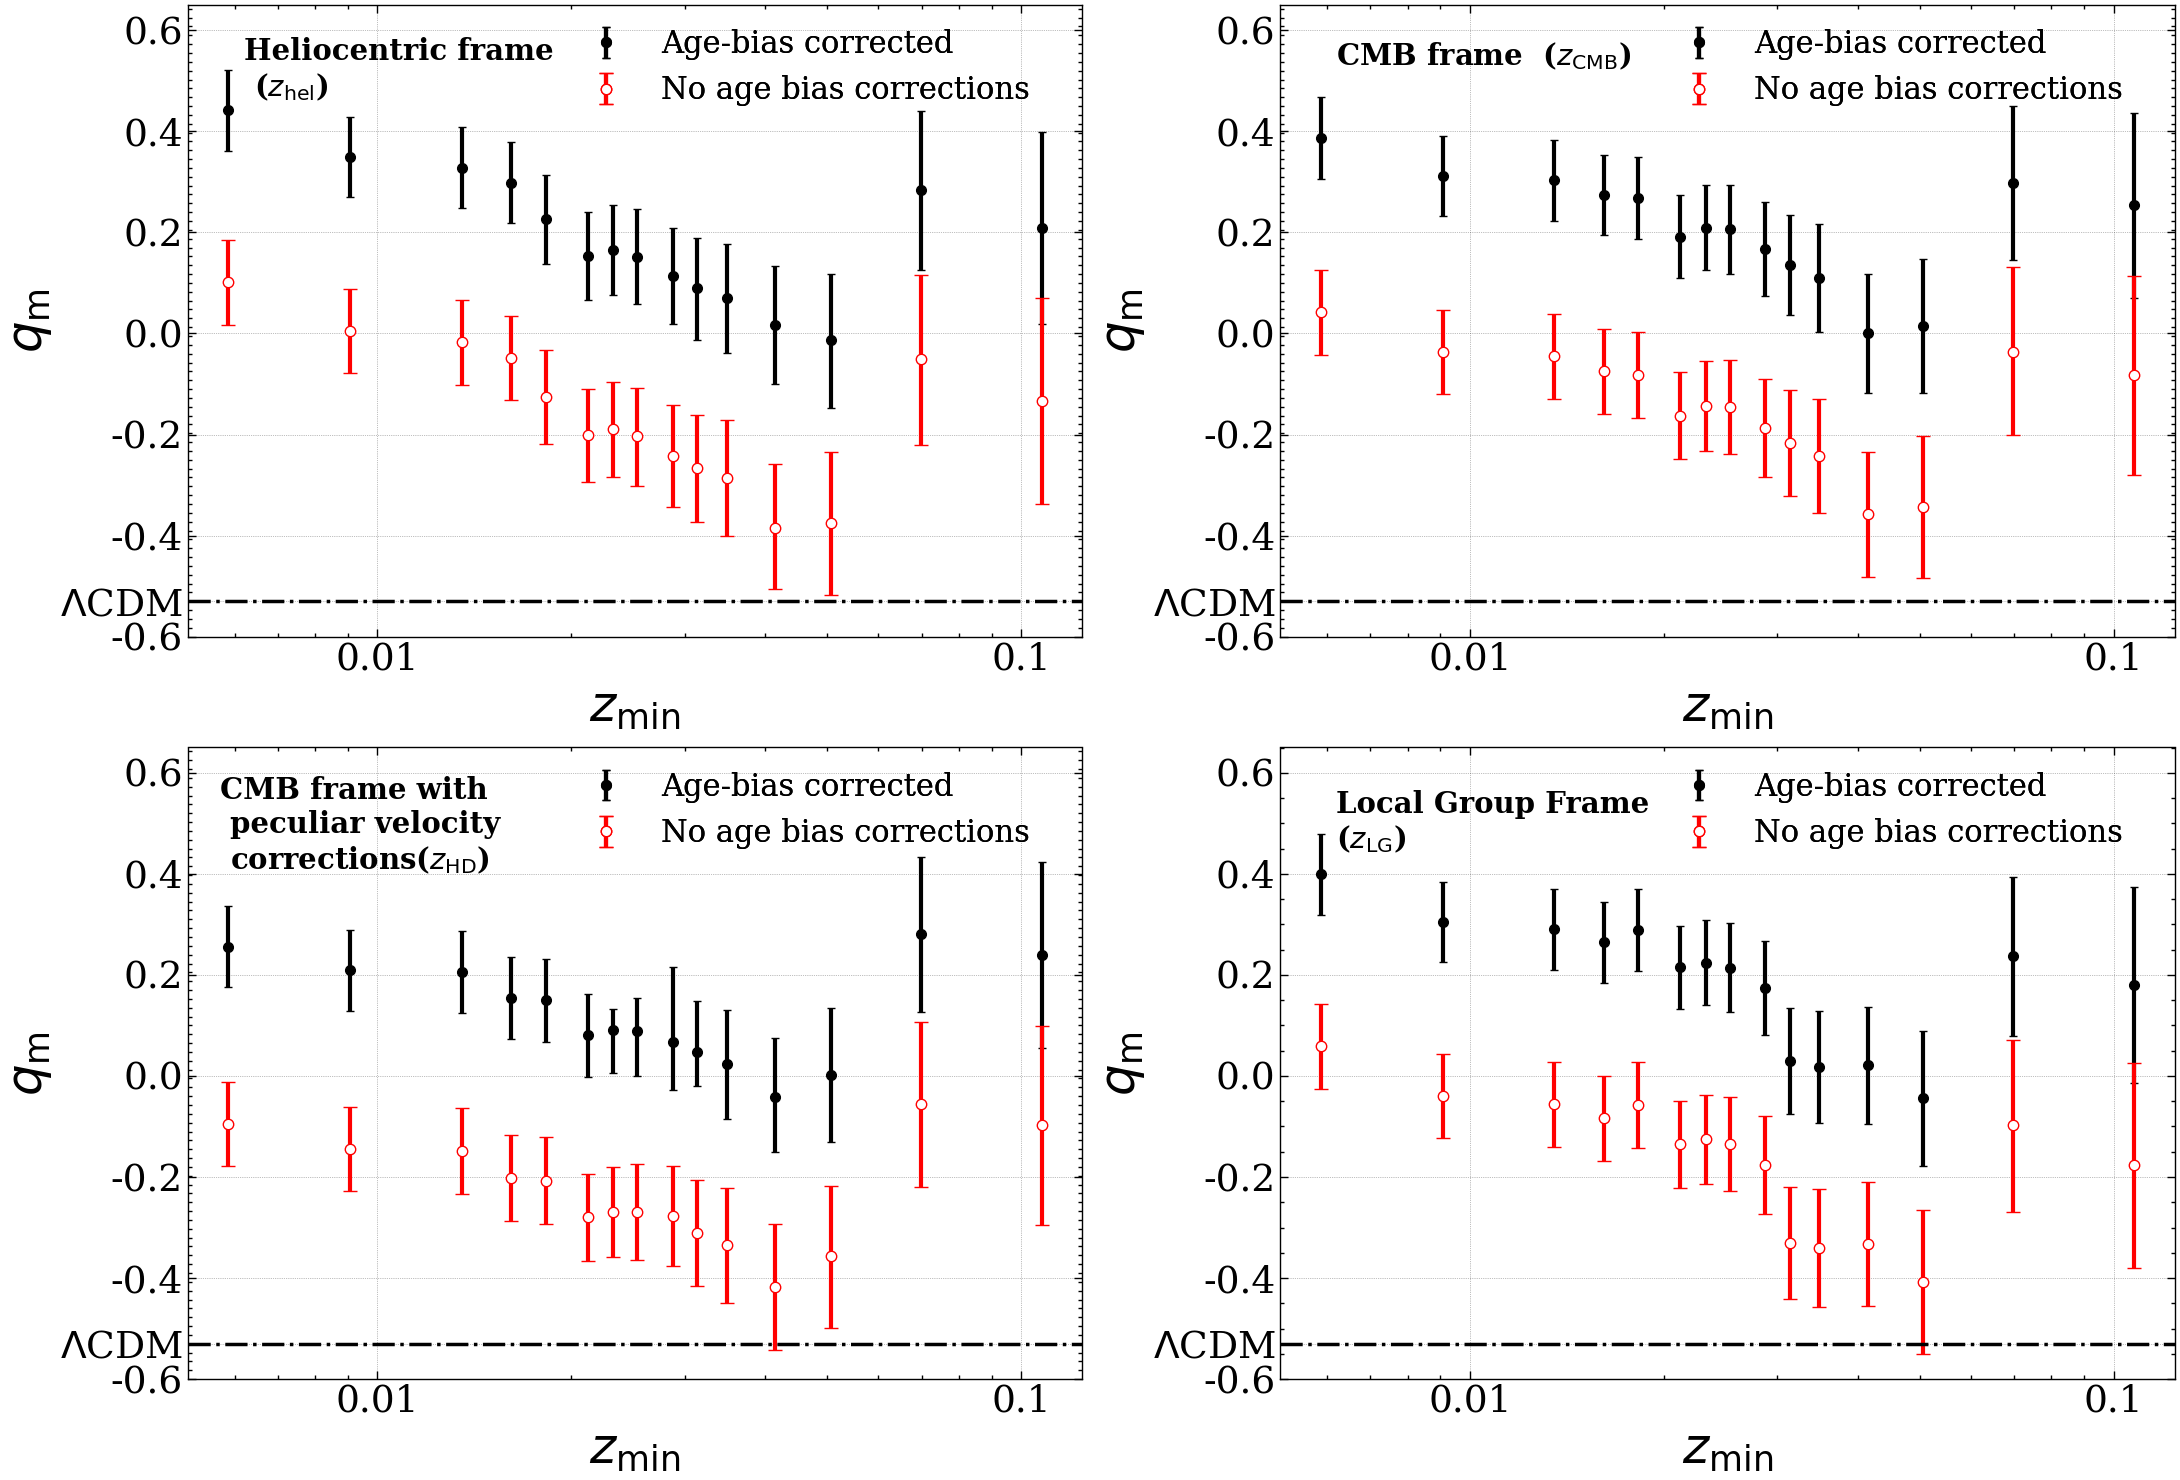

In [13]:
ar = [ 'HEL', 'CMB','HD', 'LG']
fig, axes = plt.subplots(2, 2, figsize=(22, 15))
axes = axes.flatten()
xloc=0.0052
labels=['Heliocentric frame \n ($z_{\mathrm{hel}}$)', 'CMB frame  ($z_{\mathrm{CMB}}$)' , 'CMB frame with \n peculiar velocity \n corrections($z_{\mathrm{HD}}$)','Local Group Frame \n($z_{\mathrm{LG}}$)']

# loc=[[xloc,0.15],[xloc,0.15],[xloc,0.1],[xloc,0.12]]
loc=[[xloc+0.001,0.47],[xloc+0.001,0.53],[xloc+0.0005,0.41],[xloc+0.001,0.45]]
for idx, a in enumerate(ar):
    ax = axes[idx]
    df_min = pd.read_csv(f"errors_profile_z{a}.txt", sep=',')
    
    zlims = df_min['zLIM'].values
    qm_best = df_min['QM'].values
    
    yerr_low = []
    yerr_high = []
    
    for i, roots_str in enumerate(df_min['root']):
        roots = eval(roots_str)
        roots = np.array(roots)
        q_best = qm_best[i]
        
        left_roots = roots[roots < q_best]
        right_roots = roots[roots > q_best]
        
        if len(left_roots) > 0:
            err_low = q_best - left_roots.max()
        else:
            err_low = 0
            
        if len(right_roots) > 0:
            err_high = right_roots.min() - q_best
        else:
            err_high = 0
            
        yerr_low.append(err_low)
        yerr_high.append(err_high)
    
    ax.errorbar(zlims, qm_best, yerr=[yerr_low, yerr_high], 
                fmt='o', label=f'Age-bias corrected', capsize=3, markersize=7,color='k',lw=3)
    ax.errorbar(np.array(eval(f'C2_{ar[idx]}')['zlim']), np.array(eval(f'C2_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C2_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)

    handles, labels_leg = ax.get_legend_handles_labels()
    # Manually set the location of the horizontal line label to lower left
    #ax.legend(handles, labels_leg, fontsize=22, loc='lower left', frameon=False)
    #ax.legend(handles, labels_leg, fontsize=22, loc=(0.1,0.82), frameon=False)
    ax.set_xscale('log')
    ax.tick_params(axis='x', labelsize=27)
    ax.tick_params(axis='y', labelsize=27)
    
    ax.legend(fontsize=22,loc=(0.42,0.82),frameon=False)
    ax.axhline(-0.53,ls='-.',color='k',lw=2.5)
    #ax.get_lines()[-1].set_label('$\Lambda$ CDM')
    all_handles, all_labels = ax.get_legend_handles_labels()

    main_legend = ax.legend(
        all_handles, all_labels,
        fontsize=22, loc=(0.42, 0.82), frameon=False
    )
    # ref_legend = ax.legend(
    #     [all_handles[0]], [all_labels[0]],
    #     fontsize=22, loc=(0.007,0.06,), frameon=False
    # )
    ax.get_lines()[-1].set_label(r'$\Lambda$CDM')
    yt = ax.get_yticks()
    if not np.any(np.isclose(yt, -0.53)):
        yt = np.sort(np.append(yt, -0.53))
    ax.set_yticks(yt)

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, pos: r'$\Lambda$CDM' if np.isclose(y, -0.53) else f'{y:.1f}')
    )

    ax.add_artist(main_legend)

    ax.grid(ls=':')
    ax.set_xlabel('$z_{\mathrm{min}}$',size=36)
    ax.set_ylabel('$q_{\mathrm{m}}$',size=36)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos: (float(x))))
    #plt.text(*loc[idx],labels[idx],weight='bold',fontsize=20)
    #ax.set_ylabel("$q_m$")
    #ax.legend()
    #ax.grid(True, alpha=0.3)
    #ax.set_xscale('log')
    ax.set_ylim(-0.6,0.65)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos: (float(x))))
    ax.text(*loc[idx],labels[idx],weight='bold',fontsize=21)
    #ax.set_title(f'z{a}')

plt.tight_layout()

plt.savefig('all_frames_qm_0.53_age_bias_c2.pdf',dpi=300)
plt.show()

In [8]:
C1_CMB=pd.read_csv('C1_CMB_REVB_errors.csv',index_col=0)

C1_LG=pd.read_csv('C1_LG_REVB_errors.csv',index_col=0)
C1_HD=pd.read_csv('C1_HD_REVB_errors.csv',index_col=0)

C1_HEL=pd.read_csv('C1_HEL_REVB_errors.csv',index_col=0)




C1_CMB['QD_errors'] = C1_CMB['QD_errors'].apply(json.loads)
C1_CMB['QM_errors'] = C1_CMB['QM_errors'].apply(json.loads)

C1_HEL['QD_errors'] = C1_HEL['QD_errors'].apply(json.loads)
C1_HEL['QM_errors'] = C1_HEL['QM_errors'].apply(json.loads)

C1_LG['QD_errors'] = C1_LG['QD_errors'].apply(json.loads)
C1_LG['QM_errors'] = C1_LG['QM_errors'].apply(json.loads)


C1_HD['QD_errors'] = C1_HD['QD_errors'].apply(json.loads)
C1_HD['QM_errors'] = C1_HD['QM_errors'].apply(json.loads)

HD_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_0_results.txt', delim_whitespace=True)
HEL_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_7_results.txt', delim_whitespace=True)
CMB_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_8_results.txt', delim_whitespace=True)
LG_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_9_results.txt', delim_whitespace=True)

df_error_cmb_age = pd.read_csv('CMB_QM_errors_C1_age_bias.csv')
df_error_hel_age = pd.read_csv('HEL_QM_errors_C1_age_bias.csv')
df_error_hd_age = pd.read_csv('HD_QM_errors_C1_age_bias.csv')
df_error_lg_age = pd.read_csv('LG_QM_errors_C1_age_bias.csv')



/tmp/ipykernel_60585/2153387142.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  HD_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_0_results.txt', delim_whitespace=True)
/tmp/ipykernel_60585/2153387142.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  HEL_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_7_results.txt', delim_whitespace=True)
/tmp/ipykernel_60585/2153387142.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  CMB_age = pd.read_csv('/home/shin101/cluster_mount/Analysis_C1/QM_profile_tomo_8_results.txt', delim_whitespace=True)
/tmp/ipykernel_60585/2153387142.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_cs

/tmp/ipykernel_60585/3366606598.py:98: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.array(eval(f'C2_{ar[idx]}')['zlim']), np.array(eval(f'C2_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C2_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)
/tmp/ipykernel_60585/3366606598.py:98: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(np.array(eval(f'C2_{ar[idx]}')['zlim']), np.array(eval(f'C2_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C2_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)
/tmp/ipykernel_60585/3366606598.py:98: UserWarning: marker is redundantly defined by the 'marker' keyword 

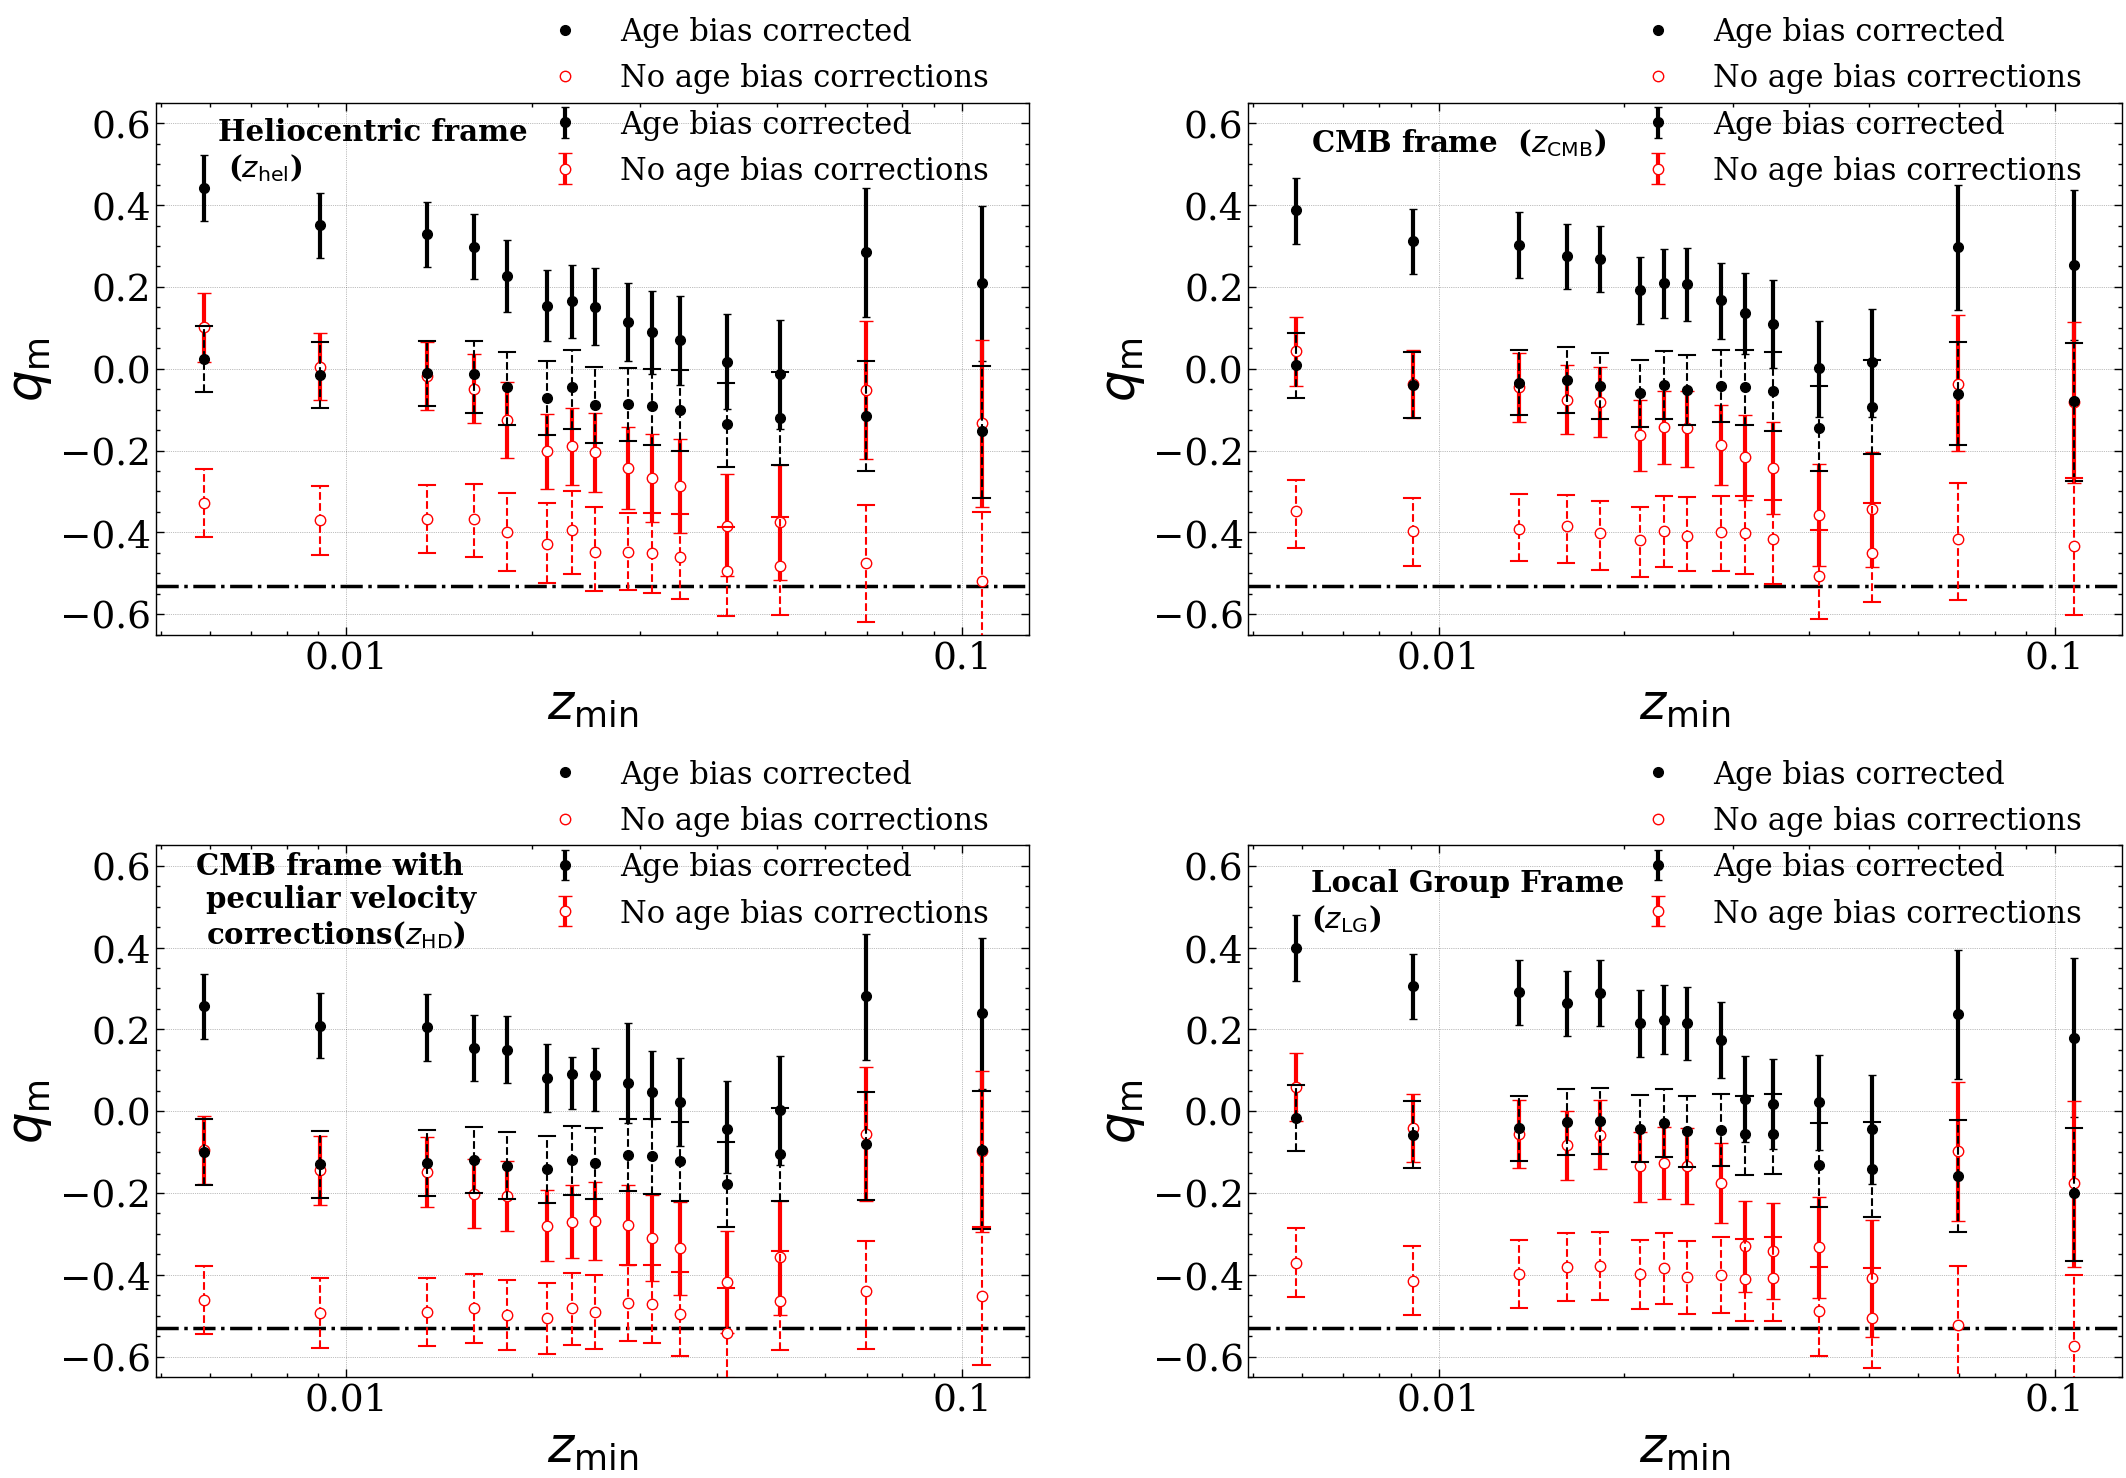

In [14]:
ar = ['HEL', 'CMB','HD', 'LG']
fig, axes = plt.subplots(2, 2, figsize=(22, 15))
axes = axes.flatten()
xloc=0.0052
labels=['Heliocentric frame \n ($z_{\mathrm{hel}}$)', 'CMB frame  ($z_{\mathrm{CMB}}$)' , 'CMB frame with \n peculiar velocity \n corrections($z_{\mathrm{HD}}$)','Local Group Frame \n($z_{\mathrm{LG}}$)']

loc=[[xloc+0.001,0.47],[xloc+0.001,0.53],[xloc+0.0005,0.41],[xloc+0.001,0.45]]
for idx, a in enumerate(ar):
    ax = axes[idx]
    df_min_c1 = pd.read_csv(f"errors_profile_z{a}.txt", sep=',')
    df_min_age_c1 = globals()[f"df_error_{a.lower()}_age"]
    zlims = df_min_c1['zLIM'].values
    qm_best_c1 = df_min_c1['QM'].values
    qm_best_age_c1 = df_min_age_c1['QM'].values
    
    yerr_low_c1 = []
    yerr_high_c1 = []
    
    for i, roots_str in enumerate(df_min_age_c1['root']):
        roots_c1 = eval(roots_str)
        roots_c2 = np.array(roots_c1)
        q_best_c1 = qm_best_age_c1[i]
        
        left_roots_c1 = roots_c2[roots_c2 < q_best_c1]
        right_roots_c1 = roots_c2[roots_c2 > q_best_c1]
        
        if len(left_roots_c1) > 0:
            err_low_c1 = q_best_c1 - left_roots_c1.max()
        else:
            err_low_c1 = 0
            
        if len(right_roots_c1) > 0:
            err_high_c1 = right_roots_c1.min() - q_best_c1
        else:
            err_high_c1 = 0
            
        yerr_low_c1.append(err_low_c1)
        yerr_high_c1.append(err_high_c1)
    
    # Plot markers only (no error bars)
    ax.plot(zlims, qm_best_age_c1, 'o', label=f'Age bias corrected', markersize=7, color='k', zorder=5)
    # Plot dashed error bars manually
    for i in range(len(zlims)):
        ax.plot([zlims[i], zlims[i]], [qm_best_age_c1[i] - yerr_low_c1[i], qm_best_age_c1[i] + yerr_high_c1[i]], 
                ls='--', color='k', lw=1.5, zorder=4)
        # Add caps
        cap_w = zlims[i] * 0.03
        ax.plot([zlims[i] - cap_w, zlims[i] + cap_w], [qm_best_age_c1[i] - yerr_low_c1[i]]*2, 
                ls='-', color='k', lw=1.5, zorder=4)
        ax.plot([zlims[i] - cap_w, zlims[i] + cap_w], [qm_best_age_c1[i] + yerr_high_c1[i]]*2, 
                ls='-', color='k', lw=1.5, zorder=4)

    # No age bias: plot markers and dashed error bars
    c1_data = eval(f'C1_{ar[idx]}')
    c1_zlims = np.array(c1_data['zlim'])
    c1_qm = np.array(c1_data['qm'])
    c1_errs = error_bars(c1_data['QM_errors'])
    ax.plot(c1_zlims, c1_qm, 'o', markersize=7.5, mfc='w', color='r', label='No age bias corrections', zorder=5)
    for i in range(len(c1_zlims)):
        ax.plot([c1_zlims[i], c1_zlims[i]], [c1_qm[i] - c1_errs[0, i], c1_qm[i] + c1_errs[1, i]], 
                ls='--', color='r', lw=1.5, zorder=4)
        cap_w = c1_zlims[i] * 0.03
        ax.plot([c1_zlims[i] - cap_w, c1_zlims[i] + cap_w], [c1_qm[i] - c1_errs[0, i]]*2, 
                ls='-', color='r', lw=1.5, zorder=4)
        ax.plot([c1_zlims[i] - cap_w, c1_zlims[i] + cap_w], [c1_qm[i] + c1_errs[1, i]]*2, 
                ls='-', color='r', lw=1.5, zorder=4)
    df_min = pd.read_csv(f"errors_profile_z{a}.txt", sep=',')
    
    zlims = df_min['zLIM'].values
    qm_best = df_min['QM'].values
    
    yerr_low = []
    yerr_high = []
    
    for i, roots_str in enumerate(df_min['root']):
        roots = eval(roots_str)
        roots = np.array(roots)
        q_best = qm_best[i]
        
        left_roots = roots[roots < q_best]
        right_roots = roots[roots > q_best]
        
        if len(left_roots) > 0:
            err_low = q_best - left_roots.max()
        else:
            err_low = 0
            
        if len(right_roots) > 0:
            err_high = right_roots.min() - q_best
        else:
            err_high = 0
            
        yerr_low.append(err_low)
        yerr_high.append(err_high)
    
    ax.errorbar(zlims, qm_best, yerr=[yerr_low, yerr_high], 
                fmt='o', label=f'Age bias corrected', capsize=3, markersize=7,color='k',lw=3)
    ax.errorbar(np.array(eval(f'C2_{ar[idx]}')['zlim']), np.array(eval(f'C2_{ar[idx]}')['qm']),marker='o',markersize=7.5,mfc='w', yerr=error_bars(eval(f'C2_{ar[idx]}')['QM_errors']),color ='r', fmt='o', capsize=5,label='No age bias corrections',lw=3)

    ax.axhline(-0.53,ls='-.',color='k',lw=2.5)
    ax.set_xscale('log')
    ax.tick_params(axis='x', labelsize=27)
    ax.tick_params(axis='y', labelsize=27)
    
    ax.legend(fontsize=22,loc=(0.42,0.82),frameon=False)
    ax.grid(ls=':')
    ax.set_xlabel('$z_{\mathrm{min}}$',size=36)
    ax.set_ylabel('$q_{\mathrm{m}}$',size=36)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: (float(x))))
    ax.set_ylim(-0.65,0.65)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: (float(x))))
    ax.text(*loc[idx],labels[idx],weight='bold',fontsize=21)

plt.tight_layout()

plt.savefig('all_frames_qm_0.53_age_bias_v2.pdf',dpi=300)
plt.show()